## CO2 Emission prediction 

# Team Members

Aalok kumar kushwaha(02)

Aalok kumar sah(04)

##  Problem Definition

### Objective
Predict the **CO2 Emissions (g/km)** of a vehicle based on its engine and fuel characteristics.

### Why Linear Regression?
- The target variable `CO2 Emissions(g/km)` is **continuous** → Regression task
- Carbon dioxide is a direct combustion product of fuel. By chemistry:
  > CO2 = fuel_consumed × carbon_content × conversion_factor
- This establishes a **theoretically linear** relationship between fuel consumption and CO2.
- Linear Regression is **interpretable**, fast, and physically justified here.

### Features (Inputs)
| Feature | Description |
|---|---|
| Engine Size (L) | Engine displacement in litres |
| Cylinders | Number of engine cylinders |
| Fuel Consumption City | L/100 km in city driving |
| Fuel Consumption Hwy | L/100 km in highway driving |
| Fuel Consumption Comb | Combined L/100 km |
| Fuel Type | Type of fuel used (encoded) |

### Target Variable
- **CO2 Emissions (g/km)** — tailpipe CO2 per kilometre driven

##  Data Collection

In [ ]:
# Import Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')  # older matplotlib fallback

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [42]:
#Load Dataset 
df = pd.read_csv('CO2_emission.csv')

print(f'Dataset Shape : {df.shape}')
print(f'Rows          : {df.shape[0]:,}')
print(f'Columns       : {df.shape[1]}')
print(f'\nColumn Names  :')
for col in df.columns:
    print(f'  • {col}')

Dataset Shape : (7385, 12)
Rows          : 7,385
Columns       : 12

Column Names  :
  • Make
  • Model
  • Vehicle Class
  • Engine Size(L)
  • Cylinders
  • Transmission
  • Fuel Type
  • Fuel Consumption City (L/100 km)
  • Fuel Consumption Hwy (L/100 km)
  • Fuel Consumption Comb (L/100 km)
  • Fuel Consumption Comb (mpg)
  • CO2 Emissions(g/km)


In [43]:
print('First 5 rows of the dataset:')
df.head()

First 5 rows of the dataset:


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [44]:
print('Statistical Summary:')
df.describe().round(2)

Statistical Summary:


,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.00,7385.00,7385.00,7385.00,7385.00,7385.00,7385.00
mean,3.16,5.62,12.56,9.04,10.98,27.48,250.58
std,1.35,1.83,3.50,2.22,2.89,7.23,58.51
min,0.90,3.00,4.20,4.00,4.10,11.00,96.00
25%,2.00,4.00,10.10,7.50,8.90,22.00,208.00
50%,3.00,6.00,12.10,8.70,10.60,27.00,246.00
75%,3.70,6.00,14.60,10.20,12.60,32.00,288.00
max,8.40,16.00,30.60,20.60,26.10,69.00,522.00


In [45]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64

## EDA & Preprocessing

In [46]:
# Handle Missing Values 
print('Missing Values per Column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '   No missing values found!')

# Fill any numerical missing values with median
num_cols_fill = ['Engine Size(L)', 'Cylinders',
                 'Fuel Consumption City (L/100 km)',
                 'Fuel Consumption Hwy (L/100 km)',
                 'Fuel Consumption Comb (L/100 km)']
for col in num_cols_fill:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'  Filled missing in: {col} with median')

print('\nMissing Values After Imputation:')
print(df.isnull().sum().sum(), 'missing values remaining')

Missing Values per Column:
   No missing values found!

Missing Values After Imputation:
0 missing values remaining


# Target Variable Analysis 

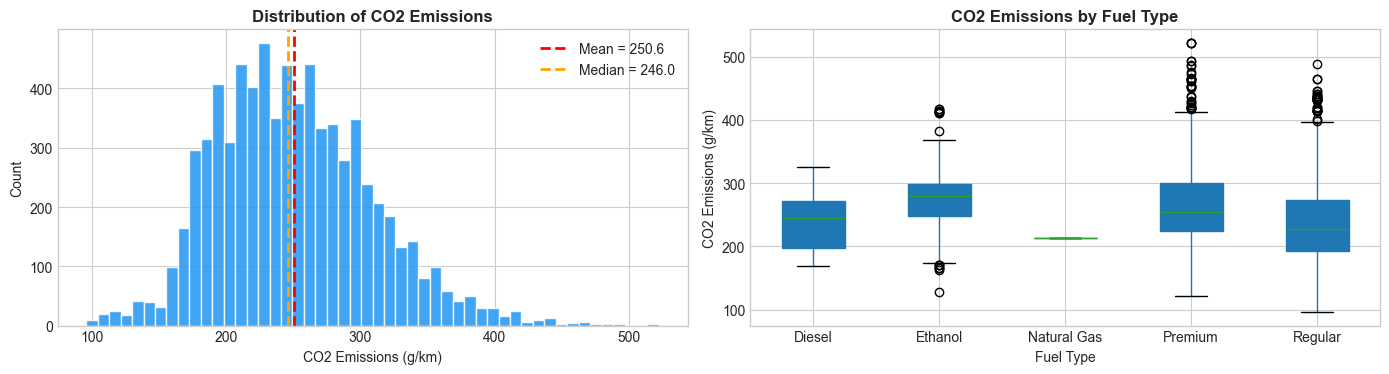


CO2 Statistics:
  Min    : 96 g/km
  Max    : 522 g/km
  Mean   : 250.6 g/km
  Std Dev: 58.5 g/km


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['CO2 Emissions(g/km)'], bins=50, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(df['CO2 Emissions(g/km)'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {df["CO2 Emissions(g/km)"].mean():.1f}')
axes[0].axvline(df['CO2 Emissions(g/km)'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median = {df["CO2 Emissions(g/km)"].median():.1f}')
axes[0].set_xlabel('CO2 Emissions (g/km)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of CO2 Emissions', fontweight='bold')
axes[0].legend()

# By Fuel Type
fuel_labels = {'X': 'Regular', 'Z': 'Premium', 'D': 'Diesel', 'E': 'Ethanol', 'N': 'Natural Gas'}
df['Fuel Label'] = df['Fuel Type'].map(fuel_labels)
df.boxplot(column='CO2 Emissions(g/km)', by='Fuel Label', ax=axes[1],
           patch_artist=True)
axes[1].set_title('CO2 Emissions by Fuel Type', fontweight='bold')
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('CO2 Emissions (g/km)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('target_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nCO2 Statistics:")
print(f"  Min    : {df['CO2 Emissions(g/km)'].min()} g/km")
print(f"  Max    : {df['CO2 Emissions(g/km)'].max()} g/km")
print(f"  Mean   : {df['CO2 Emissions(g/km)'].mean():.1f} g/km")
print(f"  Std Dev: {df['CO2 Emissions(g/km)'].std():.1f} g/km")

The figure presents CO₂ emission patterns using two plots. The left panel shows a histogram of CO₂ emissions (g/km), indicating a roughly bell-shaped distribution centered around 250 g/km, with a mean of about 250.6 g/km and a median of about 246.0 g/km, suggesting a slight right skew due to some high-emission outliers. The right panel displays boxplots comparing emissions across different fuel types—Diesel, Ethanol, Natural Gas, Premium, and Regular. It shows that Ethanol and Premium fuels generally have higher median emissions, while Diesel and Regular fall in the mid-range, and Natural Gas has the lowest and most consistent emissions. Some fuel types, particularly Premium and Regular, also exhibit several high-emission outliers.

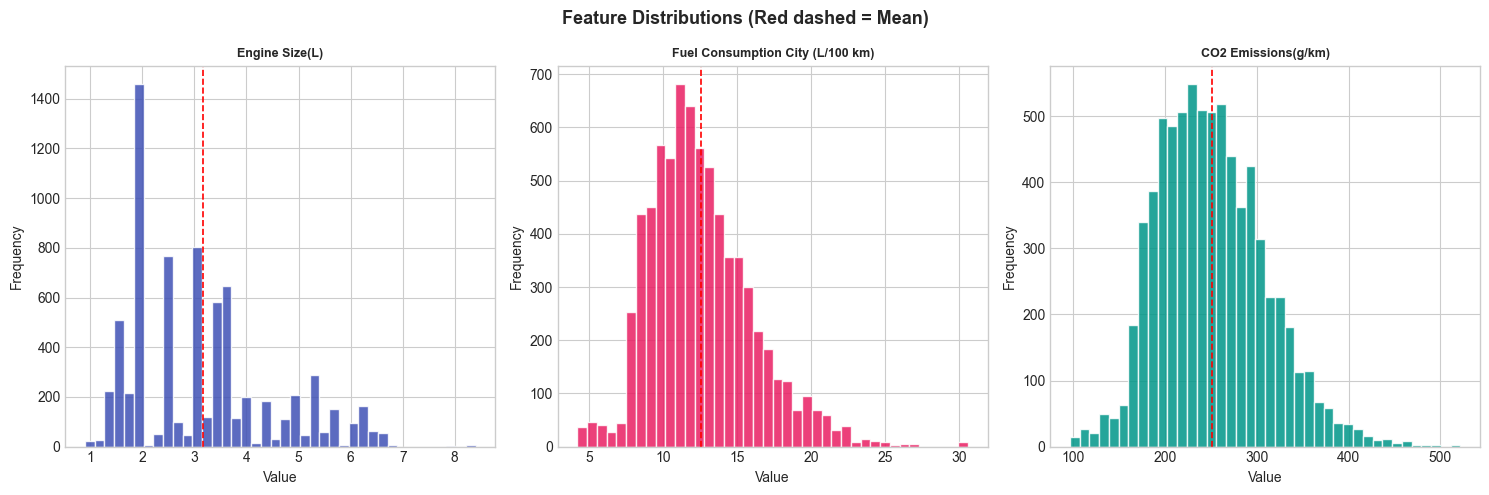

In [48]:
# Feature Distributions 
num_features = ['Engine Size(L)','Fuel Consumption City (L/100 km)','CO2 Emissions(g/km)']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = ['#3F51B5','#E91E63','#009688']

for ax, col, c in zip(axes.flat, num_features, palette):
    ax.hist(df[col], bins=40, color=c, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2)

plt.suptitle('Feature Distributions (Red dashed = Mean)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

The figure shows the **distributions of three vehicle-related features**: **engine size (L)**, **fuel consumption in city (L/100 km)**, and **CO₂ emissions (g/km)**, with the **red dashed line representing the mean value** for each variable. The engine size distribution is concentrated between **2L and 4L**, with fewer vehicles having very small or very large engines. The fuel consumption in the city is mostly clustered around **10–15 L/100 km**, indicating that most vehicles consume a moderate amount of fuel, with a slight right skew toward higher consumption values. Similarly, the CO₂ emissions distribution is centered around **about 250 g/km**, with most vehicles falling between **200 and 300 g/km**, and a small number of high-emission outliers extending beyond **400 g/km**. Overall, the plots show that larger engine sizes and higher fuel consumption correspond with typical emission levels concentrated near the mean 

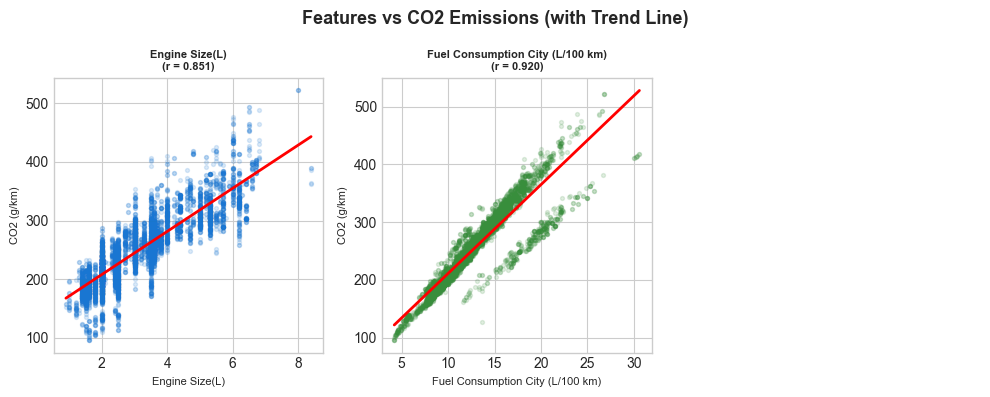

In [49]:
# Scatter Plots: Features vs CO2
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
features_scatter = ['Engine Size(L)','Fuel Consumption City (L/100 km)']
colors_s = ['#1976D2','#388E3C']

for i, (ax, col, c) in enumerate(zip(axes.flat, features_scatter, colors_s)):
    ax.scatter(df[col], df['CO2 Emissions(g/km)'], alpha=0.15, s=8, color=c)
    # Trend line
    z = np.polyfit(df[col], df['CO2 Emissions(g/km)'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=2)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('CO2 (g/km)', fontsize=8)
    corr = df[col].corr(df['CO2 Emissions(g/km)'])
    ax.set_title(f'{col}\n(r = {corr:.3f})', fontsize=8, fontweight='bold')

axes.flat[-1].axis('off')  # hide last empty subplot
plt.suptitle('Features vs CO2 Emissions (with Trend Line)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=100, bbox_inches='tight')
plt.show()

The figure presents two scatter plots showing the relationship between **CO₂ emissions (g/km)** and two vehicle features: **engine size (L)** and **city fuel consumption (L/100 km)**, each with a red trend line indicating the overall linear relationship. The left plot shows a strong positive correlation between engine size and CO₂ emissions (**r = 0.851**), meaning vehicles with larger engines generally produce higher emissions. The right plot shows an even stronger positive relationship between city fuel consumption and CO₂ emissions (**r = 0.920**), indicating that vehicles that consume more fuel in city driving tend to emit significantly more CO₂. Overall, both features are strongly associated with higher emissions, with fuel consumption showing the strongest correlation.


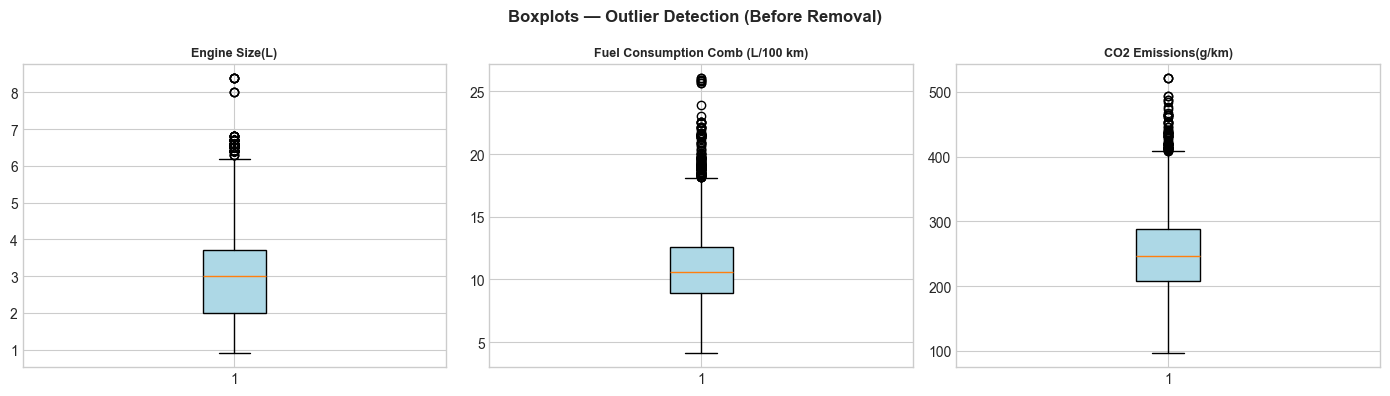

Rows before outlier removal : 7,385
Rows after  outlier removal : 7,077
Outliers removed            : 308


In [50]:
# Outlier Detection & Removal (IQR Method)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cols_box = ['Engine Size(L)', 'Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)']
for ax, col in zip(axes, cols_box):
    ax.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='lightblue'))
    ax.set_title(f'{col}', fontsize=9, fontweight='bold')
plt.suptitle('Boxplots — Outlier Detection (Before Removal)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_before.png', dpi=100, bbox_inches='tight')
plt.show()

before = df.shape[0]
for col in cols_box:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df  = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

print(f'Rows before outlier removal : {before:,}')
print(f'Rows after  outlier removal : {df.shape[0]:,}')
print(f'Outliers removed            : {before - df.shape[0]:,}')

The figure shows **three boxplots used for outlier detection before data cleaning** for the variables **Engine Size (L), Fuel Consumption Combined (L/100 km), and CO₂ Emissions (g/km)**. Each boxplot displays the distribution of values using the median (central line), interquartile range (the box), and whiskers representing the spread of most observations. Several points appear above the upper whiskers in all three plots, indicating the presence of **outliers**, especially in **Fuel Consumption** and **CO₂ Emissions**, where many vehicles have unusually high values. Similarly, **Engine Size** also contains a few extreme values above the typical range. These boxplots suggest that the dataset contains **high-end outliers that may need to be removed or treated** before performing further analysis or building machine learning models.


In [51]:
# Encoding Categorical Variables 
le = LabelEncoder()
df['Fuel Type Encoded'] = le.fit_transform(df['Fuel Type'])

print('Fuel Type Label Encoding:')
fuel_map = {'D': 'Diesel', 'E': 'Ethanol', 'N': 'Natural Gas', 'X': 'Regular Gasoline', 'Z': 'Premium Gasoline'}
for orig, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {orig} ({fuel_map.get(orig, orig)}) → {enc}')

# Also encode Vehicle Class for potential use
le2 = LabelEncoder()
df['Vehicle Class Encoded'] = le2.fit_transform(df['Vehicle Class'])
print(f'\nVehicle Class encoded: {df["Vehicle Class"].nunique()} unique classes')

Fuel Type Label Encoding:
  D (Diesel) → 0
  E (Ethanol) → 1
  N (Natural Gas) → 2
  X (Regular Gasoline) → 3
  Z (Premium Gasoline) → 4

Vehicle Class encoded: 16 unique classes


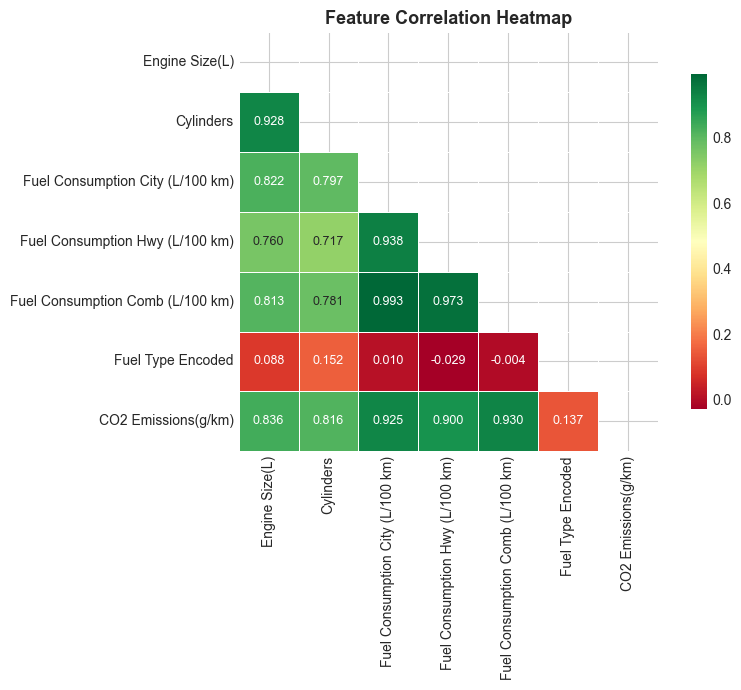

Correlation with CO2 Emissions (sorted):
Fuel Consumption Comb (L/100 km)    0.9299
Fuel Consumption City (L/100 km)    0.9252
Fuel Consumption Hwy (L/100 km)     0.9004
Engine Size(L)                      0.8359
Cylinders                           0.8162
Fuel Type Encoded                   0.1369
Name: CO2 Emissions(g/km), dtype: float64


In [52]:
# Correlation Heatmap 
corr_cols = ['Engine Size(L)', 'Cylinders',
             'Fuel Consumption City (L/100 km)',
             'Fuel Consumption Hwy (L/100 km)',
             'Fuel Consumption Comb (L/100 km)',
             'Fuel Type Encoded', 'CO2 Emissions(g/km)']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print('Correlation with CO2 Emissions (sorted):')
print(corr_matrix['CO2 Emissions(g/km)'].drop('CO2 Emissions(g/km)').sort_values(ascending=False).round(4))

The figure presents a **feature correlation heatmap** that illustrates the strength of relationships between different variables in the dataset. Dark green colors represent **strong positive correlations**, while red shades indicate **weak or near-zero correlations**. The heatmap shows that **CO₂ Emissions (g/km)** has a very strong positive correlation with **Fuel Consumption City (0.925)**, **Fuel Consumption Hwy (0.900)**, and **Fuel Consumption Comb (0.930)**, indicating that vehicles with higher fuel consumption produce more CO₂ emissions. **Engine Size (0.836)** and **Cylinders (0.816)** also show strong positive correlations with CO₂ emissions, suggesting that larger engines and more cylinders tend to increase emissions. Additionally, fuel consumption variables are highly correlated with each other (values close to 1), meaning they provide similar information. In contrast, **Fuel Type Encoded** has a very weak correlation with most variables, indicating that fuel type has a relatively smaller direct relationship with CO₂ emissions in this dataset. Overall, the heatmap highlights **fuel consumption and engine characteristics as the most influential factors affecting CO₂ emissions**. 


In [53]:
# Feature Selection, Scaling & Train-Test Split 
feature_cols = ['Engine Size(L)', 'Cylinders',
                'Fuel Consumption City (L/100 km)',
                'Fuel Consumption Hwy (L/100 km)',
                'Fuel Consumption Comb (L/100 km)',
                'Fuel Type Encoded']

X = df[feature_cols]
y = df['CO2 Emissions(g/km)']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Train-Test Split:')
print(f'  Training samples : {X_train_scaled.shape[0]:,}')
print(f'  Testing  samples : {X_test_scaled.shape[0]:,}')
print(f'  Test Size        : 20%')
print(f'\nFeatures used:')
for f in feature_cols:
    print(f'  • {f}')

Train-Test Split:
  Training samples : 5,661
  Testing  samples : 1,416
  Test Size        : 20%

Features used:
  • Engine Size(L)
  • Cylinders
  • Fuel Consumption City (L/100 km)
  • Fuel Consumption Hwy (L/100 km)
  • Fuel Consumption Comb (L/100 km)
  • Fuel Type Encoded


## Model Building — Linear Regression

In [54]:
# Train Model 
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(' Linear Regression model trained successfully!')
print(f'\nIntercept (β₀) : {model.intercept_:.4f}')
print('\nFeature Coefficients:')
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

 Linear Regression model trained successfully!

Intercept (β₀) : 245.1728

Feature Coefficients:
                         Feature  Coefficient
Fuel Consumption Comb (L/100 km)    43.056933
                  Engine Size(L)     6.628194
               Fuel Type Encoded     5.823728
                       Cylinders     5.704934
 Fuel Consumption Hwy (L/100 km)     3.147036
Fuel Consumption City (L/100 km)    -6.594590


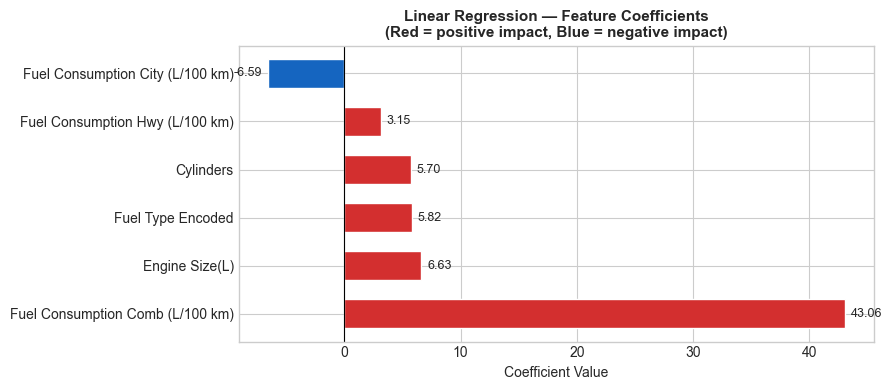

In [55]:
plt.figure(figsize=(9, 4))
colors = ['#d32f2f' if c > 0 else '#1565C0' for c in coef_df['Coefficient']]
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white', height=0.6)
plt.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, coef_df['Coefficient']):
    plt.text(val + (0.5 if val >= 0 else -0.5), bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.xlabel('Coefficient Value')
plt.title('Linear Regression — Feature Coefficients\n(Red = positive impact, Blue = negative impact)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('coefficients.png', dpi=100, bbox_inches='tight')
plt.show()

The figure shows a **horizontal bar chart of feature coefficients from a linear regression model**, indicating how each feature influences **CO₂ Emissions (g/km)**. Red bars represent **positive impacts**, meaning the feature increases CO₂ emissions, while the blue bar represents a **negative impact**, indicating a decrease. The chart reveals that **Fuel Consumption Combined (L/100 km)** has the strongest positive effect on CO₂ emissions with the largest coefficient (about **43.06**), making it the most influential predictor in the model. **Engine Size**, **Fuel Type Encoded**, **Cylinders**, and **Fuel Consumption Hwy** also contribute positively but with smaller effects. In contrast, **Fuel Consumption City (L/100 km)** has a **negative coefficient (-6.59)**, suggesting an inverse relationship with CO₂ emissions in the model, possibly due to multicollinearity with other fuel consumption variables. Overall, the plot highlights that **combined fuel consumption is the dominant factor affecting predicted CO₂ emissions** in the regression model. 


## 5.  Model Evaluation
**Metrics for Linear Regression:** R², MSE, RMSE, MAE

In [56]:
# Predictions & Metrics 
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)
mse_test   = mean_squared_error(y_test, y_pred_test)
rmse_test  = np.sqrt(mse_test)
mae_test   = mean_absolute_error(y_test, y_pred_test)

# Cross Validation
cv_scores  = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=5, scoring='r2')

print('       MODEL EVALUATION RESULTS\n')

print(f'  R² Score  (Train) : {r2_train:.4f}')
print(f'  R² Score  (Test)  : {r2_test:.4f}  ← {r2_test*100:.2f}% variance explained')
print(f'  MSE               : {mse_test:.4f}')
print(f'  RMSE              : {rmse_test:.4f} g/km')
print(f'  MAE               : {mae_test:.4f} g/km')
print(f'  Cross-Val R² (5x) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 50)

       MODEL EVALUATION RESULTS

  R² Score  (Train) : 0.8994
  R² Score  (Test)  : 0.9022  ← 90.22% variance explained
  MSE               : 273.4581
  RMSE              : 16.5366 g/km
  MAE               : 10.2631 g/km
  Cross-Val R² (5x) : 0.8988 ± 0.0085


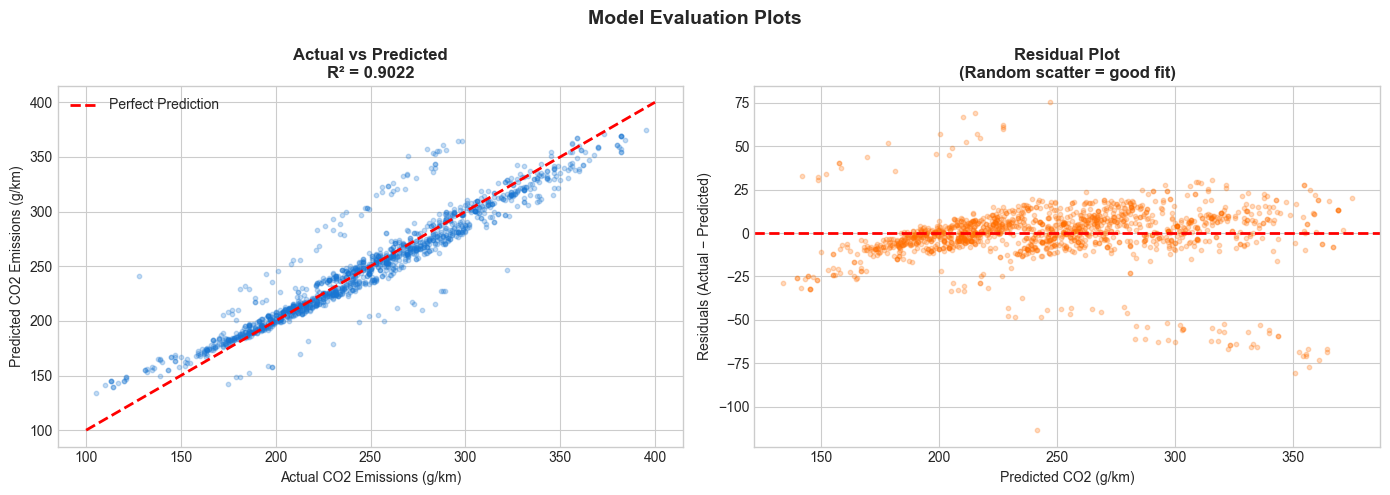

In [57]:
# Evaluation Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.25, s=10, color='#1976D2')
lims = [min(y_test.min(), y_pred_test.min())-5,
        max(y_test.max(), y_pred_test.max())+5]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual CO2 Emissions (g/km)')
axes[0].set_ylabel('Predicted CO2 Emissions (g/km)')
axes[0].set_title(f'Actual vs Predicted\nR² = {r2_test:.4f}', fontweight='bold')
axes[0].legend()

# Plot 2: Residuals
residuals = y_test.values - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.25, s=10, color='#FF6F00')
axes[1].axhline(0, color='red', linewidth=2, linestyle='--')
axes[1].set_xlabel('Predicted CO2 (g/km)')
axes[1].set_ylabel('Residuals (Actual − Predicted)')
axes[1].set_title('Residual Plot\n(Random scatter = good fit)', fontweight='bold')

plt.suptitle('Model Evaluation Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_plots.png', dpi=100, bbox_inches='tight')
plt.show()

The figure shows **model evaluation plots** for a CO₂ emission prediction model. The **Actual vs Predicted** scatter plot indicates that most predicted values lie close to the red dashed **perfect prediction line**, demonstrating strong agreement between actual and predicted CO₂ emissions. The **R² value of 0.9022** suggests that the model explains about **90% of the variability** in the data, indicating high predictive accuracy. The **Residual Plot** displays the residuals (Actual − Predicted) against predicted values, where the points are mostly randomly scattered around the zero line, implying that the model errors are generally unbiased and the model fits the data well. Although a few larger residuals and outliers appear, particularly at higher predicted values, the overall pattern suggests that the model performs effectively with a good fit to the dataset. 

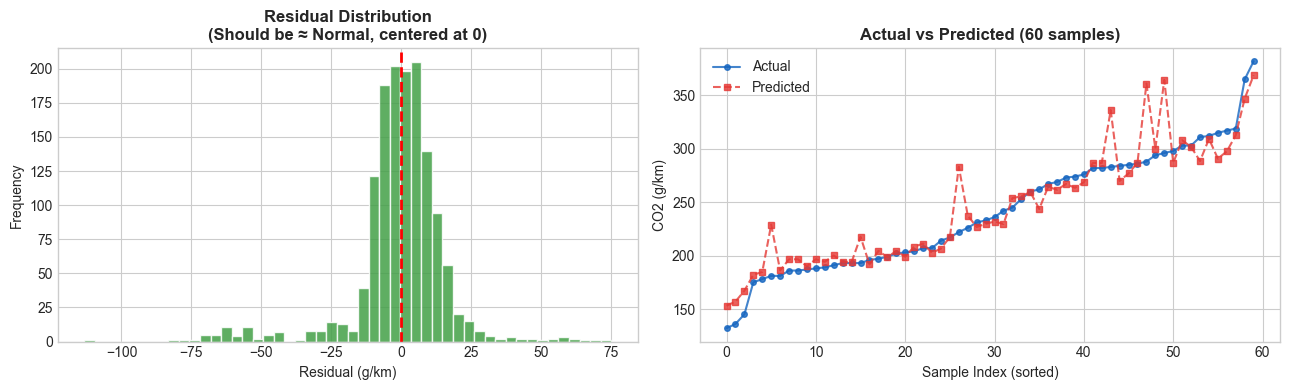

In [58]:
# Residual Distribution 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(residuals, bins=50, color='#43A047', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual (g/km)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Residual Distribution\n(Should be ≈ Normal, centered at 0)', fontweight='bold')

# Predicted vs Actual line plot (sample 100)
idx = np.random.choice(len(y_test), 60, replace=False)
sample_y   = y_test.values[idx]
sample_yp  = y_pred_test[idx]
sort_idx   = np.argsort(sample_y)
axes[1].plot(range(60), sample_y[sort_idx],   'o-', color='#1565C0', markersize=4, label='Actual', alpha=0.8)
axes[1].plot(range(60), sample_yp[sort_idx],  's--', color='#E53935', markersize=4, label='Predicted', alpha=0.8)
axes[1].set_xlabel('Sample Index (sorted)')
axes[1].set_ylabel('CO2 (g/km)')
axes[1].set_title('Actual vs Predicted (60 samples)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

The figure presents two plots used to further evaluate the performance of a CO₂ emission prediction model. The **Residual Distribution** histogram shows that most residual values are concentrated around zero, forming an approximately normal distribution centered near the red dashed line, which indicates that the model’s prediction errors are generally small and unbiased. A few values spread toward the extremes suggest the presence of minor outliers. The **Actual vs Predicted (60 samples)** line plot compares the actual CO₂ emission values with the predicted values for a subset of samples, where the predicted trend closely follows the actual trend across the dataset. Although there are some fluctuations and slight deviations at certain points, the overall pattern demonstrates that the model captures the general behavior of the data effectively and provides reasonably accurate predictions. 

In [59]:
# Sample Predictions Table 
sample_idx  = X_test.iloc[:10].copy()
s_scaled    = scaler.transform(sample_idx)
s_pred      = model.predict(s_scaled)
s_actual    = y_test.iloc[:10].values

results_df = pd.DataFrame({
    'Engine Size(L)'    : sample_idx['Engine Size(L)'].values,
    'Cylinders'         : sample_idx['Cylinders'].values,
    'FC Comb (L/100km)' : sample_idx['Fuel Consumption Comb (L/100 km)'].values,
    'Actual CO2'        : s_actual,
    'Predicted CO2'     : np.round(s_pred, 1),
    'Error (g/km)'      : np.round(np.abs(s_actual - s_pred), 1)
})
print('Sample Predictions:')
results_df

Sample Predictions:


,Engine Size(L),Cylinders,FC Comb (L/100km),Actual CO2,Predicted CO2,Error (g/km)
0,1.8,4,8.4,197,201.9,4.9
1,3.5,6,9.5,222,228.5,6.5
2,3.6,6,11.2,263,256.4,6.6
3,3.2,6,11.1,259,252.8,6.2
4,1.6,4,7.9,186,186.9,0.9
5,5.0,8,13.8,324,315.5,8.5
6,2.4,4,9.1,209,209.3,0.3
7,2.0,4,8.2,189,193.8,4.8
8,1.4,4,8.4,195,193.7,1.3
9,3.6,6,11.3,265,259.6,5.4
